C:\Users\cesia\AppData\Local\Temp\ipykernel_23524\2381549023.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eurostat['date'] = pd.to_datetime(df_eurostat['date'])


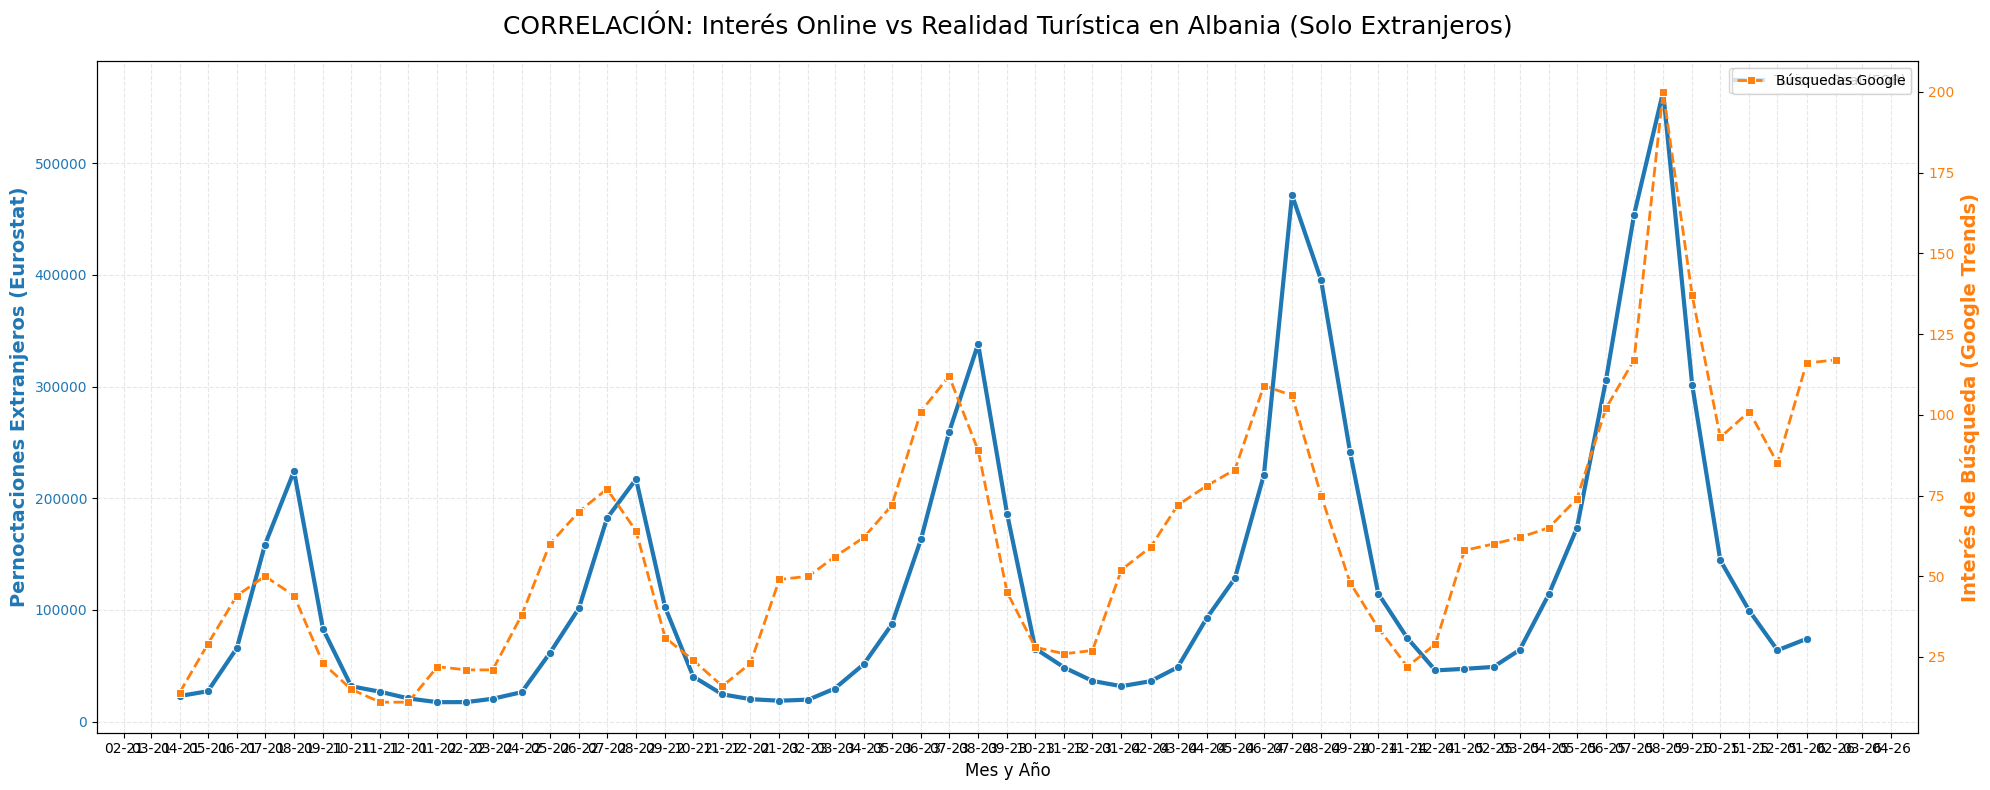


Coeficiente de Correlación entre Búsquedas y Pernoctaciones: 0.34


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. CARGAR Y PREPARAR DATOS DE EUROSTAT
df_eurostat = pd.read_csv('cleaned_tourism_data.csv')
df_eurostat['date'] = pd.to_datetime(df_eurostat['date'])

# FILTRO CRÍTICO: Solo Albania, solo Extranjeros (FOR), solo Total alojamientos (I551-I553)
al_real = df_eurostat[
    (df_eurostat['geo'] == 'AL') & 
    (df_eurostat['c_resid'] == 'FOR') & 
    (df_eurostat['nace_r2'] == 'I551-I553') & 
    (df_eurostat['date'] >= '2020-01-01')
].copy()

# 2. CARGAR Y PREPARAR DATOS DE GOOGLE TRENDS
try:
    df_trends = pd.read_csv('time_series_Worldwide_hotel.csv') # Asegúrate de que el nombre sea correcto
    df_trends.columns = ['date', 'search_volume_hotel','search_volume_airbnb', 'search_volume'] # Renombrar columnas para claridad
    df_trends['date'] = pd.to_datetime(df_trends['date'])
    
    # Agrupamos por mes para que coincida con Eurostat
    df_trends_monthly = df_trends.resample('MS', on='date').mean().reset_index()
    
    # 3. UNIR AMBOS DATASETS
    df_combined = pd.merge(al_real, df_trends_monthly, on='date', how='inner')

    # 4. CREAR EL PLOT DE CORRELACIÓN SIN SOMBRAS
    fig, ax1 = plt.subplots(figsize=(20, 8))

    # Línea Eurostat (Eje Izquierdo) - Usamos errorbar=None para línea limpia
    color_real = '#1f77b4' # Azul profesional
    ax1.set_xlabel('Mes y Año', fontsize=12)
    ax1.set_ylabel('Pernoctaciones Extranjeros (Eurostat)', color=color_real, fontsize=14, fontweight='bold')
    sns.lineplot(data=df_combined, x='date', y='value', color=color_real, 
                 marker='o', linewidth=3, ax=ax1, label='Turismo Real (FOR)', errorbar=None)
    ax1.tick_params(axis='y', labelcolor=color_real)

    # Línea Google Trends (Eje Derecho)
    ax2 = ax1.twinx() 
    color_trends = '#ff7f0e' # Naranja Google
    ax2.set_ylabel('Interés de Búsqueda (Google Trends)', color=color_trends, fontsize=14, fontweight='bold')
    sns.lineplot(data=df_combined, x='date', y='search_volume', color=color_trends, 
                 marker='s', linestyle='--', linewidth=2, ax=ax2, label='Búsquedas Google', errorbar=None)
    ax2.tick_params(axis='y', labelcolor=color_trends)

    # 5. CONFIGURACIÓN EJE X (Todos los meses visibles)
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%y'))
    plt.xticks(rotation=90)

    plt.title('CORRELACIÓN: Interés Online vs Realidad Turística en Albania (Solo Extranjeros)', fontsize=18, pad=20)
    ax1.grid(True, linestyle='--', alpha=0.3)
    
    fig.tight_layout()
    plt.show()

    # Cálculo de Correlación
    correlation = df_combined['value'].corr(df_combined['search_volume'])
    print(f"\nCoeficiente de Correlación entre Búsquedas y Pernoctaciones: {correlation:.2f}")

except Exception as e:
    print(f"Error: {e}")

In [5]:
# Probamos un desfase de 1 y 2 meses (La gente busca antes de viajar)
df_combined['search_lag1'] = df_combined['search_volume'].shift(1)
df_combined['search_lag2'] = df_combined['search_volume'].shift(2)

print(f"Correlación original: {df_combined['value'].corr(df_combined['search_volume']):.2f}")
print(f"Correlación con 1 mes de antelación: {df_combined['value'].corr(df_combined['search_lag1']):.2f}")
print(f"Correlación con 2 meses de antelación: {df_combined['value'].corr(df_combined['search_lag2']):.2f}")

Correlación original: 0.34
Correlación con 1 mes de antelación: 0.32
Correlación con 2 meses de antelación: 0.33


In [6]:
# Crear etiquetas de alerta basadas en la desviación
df_combined['alert_level'] = 'Green'
df_combined.loc[df_combined['deviation'] > df_combined['deviation'].std() * 1.0, 'alert_level'] = 'Amber'
df_combined.loc[df_combined['deviation'] > df_combined['deviation'].std() * 1.5, 'alert_level'] = 'Red'

# Ver cuántas alertas rojas hemos tenido
print(df_combined['alert_level'].value_counts())

KeyError: 'deviation'